# ECB SPF — Real GDP (RGDP) rank CIs

Parallel to [HICP_CI.ipynb](./HICP_CI.ipynb), but ranking forecasters on their
**year-on-year real GDP growth** forecasts. Pipeline is identical:
`load_ecb_spf` → `error_panel` → `select_top_forecasters` → rank CI / τ-best,
with a pre-2021 subsample run at the end to check whether the COVID episode
is what's keeping the CIs uninformative.

## Data sources

**Forecasts** — ECB Survey of Professional Forecasters, individual responses,
`GROWTH EXPECTATIONS; YEAR-ON-YEAR CHANGE IN REAL GDP` block of each survey
CSV in `data/ecb/individual_forecasts/`. Public download:
<https://www.ecb.europa.eu/stats/ecb_surveys/survey_of_professional_forecasters/html/index.en.html>.
Each row gives the forecaster's point forecast (in % YoY) for a target period
encoded by the `TARGET_PERIOD` column (year `YYYY` for annual averages, or
quarter `YYYYQq` for a specific quarter).

**Realizations** — Eurostat dataset `namq_10_gdp` (GDP and main components,
quarterly national accounts).

  - **Filters**: `unit = CLV_I20` (chain-linked volumes, index 2020=100),
                  `na_item = B1GQ` (GDP at market prices),
                  `s_adj = SCA` (seasonally and calendar adjusted),
                  `geo = EA` (Euro area aggregate).
  - **Browser link**: <https://ec.europa.eu/eurostat/databrowser/view/namq_10_gdp/default/table?lang=en>.
  - **API URL used here**: `https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/namq_10_gdp/Q.CLV_I20.SCA.B1GQ.EA` — returns SDMX-ML `GenericData` with a single `<g:Series>` (~11 KB).
  - **On-disk file**: `../../data/ecb/namq_10_gdp_EA_RGDP.xml`.

## The transformation

Eurostat publishes a quarterly **level** — a chain-linked volume index
normalised so that the 2020 calendar-year average equals 100. ECB SPF
forecasters predict **year-on-year growth rates in %**. The level → growth
transformation is

$$y_t \;=\; \Bigl(\frac{\mathrm{Index}_t}{\mathrm{Index}_{t-4}} - 1\Bigr) \times 100,$$

applied at quarterly frequency. The forecast error is then

$$e_{i,t} \;=\; \mathrm{POINT}_{i,t} \;-\; y_t.$$

For annual `TARGET_PERIOD = "YYYY"` we average the four quarterly $y_t$'s
for that calendar year (`annual_method="mean"`, the default). For
`TARGET_PERIOD = "YYYYQq"` we use $y_t$ directly for that quarter. These
rules live in `rgdp_realized_by_target_period` so the notebook stays focused
on the CI analysis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rankci import (
    rank_ci_stepwise_pairwise,
    rank_ci_marginal_pairwise,
    tau_best_pairwise,
    tau_best_from_rank_ci,
    compute_pairwise,
)
from rankci.data.ecb import (
    load_ecb_spf,
    add_horizon,
    error_panel,
    load_rgdp_index_sdmx,
    rgdp_yoy_from_index,
    rgdp_realized_by_target_period,
)
from rankci.data.panel import select_top_forecasters

DATA_DIR  = '../../data/ecb/individual_forecasts'
RGDP_REAL = '../../data/ecb/namq_10_gdp_EA_RGDP.xml'

## 1. Load and check the Eurostat index

The SDMX-ML file contains exactly one `<g:Series>` after the dimension-path
filter is applied. `load_rgdp_index_sdmx` asserts the series key matches the
filters we expected (a defensive check in case the file is ever re-fetched
with different parameters).

RGDP CLV index: 125 quarters, 1995Q1 → 2026Q1
2020 average: 100.0000  (should be exactly 100)


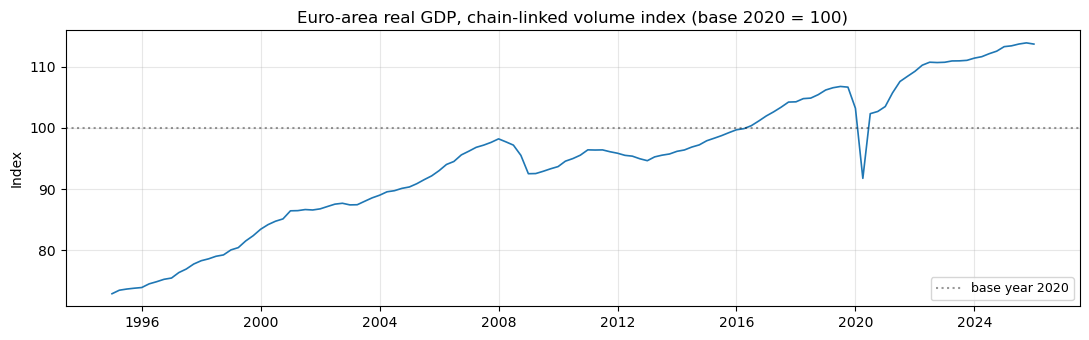

In [2]:
idx = load_rgdp_index_sdmx(RGDP_REAL, expected_dims={
    'unit': 'CLV_I20', 'na_item': 'B1GQ', 's_adj': 'SCA', 'geo': 'EA',
})
print(f'RGDP CLV index: {len(idx)} quarters, {idx.index.min()} → {idx.index.max()}')
print(f'2020 average: {idx[idx.index.year == 2020].mean():.4f}  (should be exactly 100)')

plt.figure(figsize=(11, 3.5))
plt.plot(idx.index.to_timestamp(), idx.values, linewidth=1.2)
plt.axhline(100, color='k', linestyle=':', alpha=0.4, label='base year 2020')
plt.title('Euro-area real GDP, chain-linked volume index (base 2020 = 100)')
plt.ylabel('Index')
plt.grid(alpha=0.3)
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## 2. Year-on-year growth: index → rate

$y_t = (\mathrm{Index}_t / \mathrm{Index}_{t-4} - 1) \times 100$. The first
four observations have no four-quarter lag, so the YoY series starts at
$t=$ 1996Q1.

YoY series: 121 quarters, 1996Q1 → 2026Q1
  2008Q4: y_t = -2.18%
  2009Q1: y_t = -5.80%
  2009Q2: y_t = -5.30%
  2020Q1: y_t = -2.82%
  2020Q2: y_t = -13.90%
  2021Q2: y_t = +15.24%
  2022Q1: y_t = +5.57%


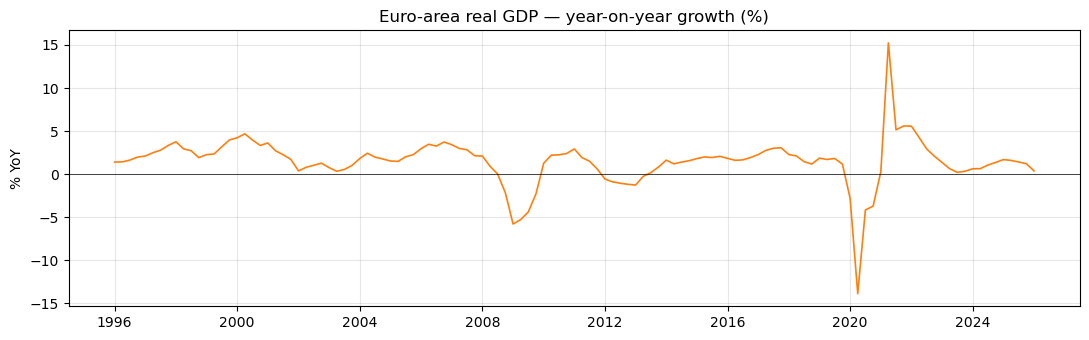

In [3]:
yoy = rgdp_yoy_from_index(idx)
print(f'YoY series: {len(yoy)} quarters, {yoy.index.min()} → {yoy.index.max()}')

# Sanity check on a few crisis quarters
for q in ['2008Q4', '2009Q1', '2009Q2', '2020Q1', '2020Q2', '2021Q2', '2022Q1']:
    per = pd.Period(q, freq='Q')
    if per in yoy.index:
        print(f'  {q}: y_t = {yoy[per]:+.2f}%')

plt.figure(figsize=(11, 3.5))
plt.plot(yoy.index.to_timestamp(), yoy.values, linewidth=1.2, color='C1')
plt.axhline(0, color='k', linewidth=0.5)
plt.title('Euro-area real GDP — year-on-year growth (%)')
plt.ylabel('% YoY')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Align realizations to ECB SPF `TARGET_PERIOD` strings

ECB SPF RGDP uses two target shapes: annual (`"YYYY"`, mean of 4 quarterly
rates) and quarterly (`"YYYYQq"`, the YoY rate of that single quarter).
`rgdp_realized_by_target_period` produces a Series whose index strings match
the survey CSVs exactly, so `error_panel` can align them with a single
`Series.map` call.

In [4]:
realized = rgdp_realized_by_target_period(yoy, annual_method='mean')
print(f'Realized series: {len(realized)} target_period keys')

spot = ['2008', '2008Q4', '2009', '2009Q2', '2020', '2020Q2', '2022', '2022Q1', '2025']
for k in spot:
    v = realized.get(k)
    print(f'  {k:8s} -> {v:+.2f}%' if v is not None else f'  {k:8s} -> (missing)')

Realized series: 151 target_period keys
  2008     -> +0.21%
  2008Q4   -> -2.18%
  2009     -> -4.45%
  2009Q2   -> -5.30%
  2020     -> -6.15%
  2020Q2   -> -13.90%
  2022     -> +3.71%
  2022Q1   -> +5.57%
  2025     -> +1.47%


## 4. ECB SPF RGDP forecasts → squared-error panel

Annual target, horizon `h=3` quarters from the survey to the target. This is
the same convention used in `HICP_CI.ipynb`, so the two notebooks rank the
same forecasters under the same horizon definition.

In [5]:
spf = load_ecb_spf(DATA_DIR, indicators=['RGDP'])
spf = add_horizon(spf)
print(f'ECB SPF RGDP rows: {len(spf):,}')
print(f'Survey coverage: ({spf.survey_year.min()},Q{spf.survey_quarter.min()}) → '
      f'({spf.survey_year.max()},Q{spf.survey_quarter.max()})')
print(f'Target kinds: {dict(spf.target_kind.value_counts())}')

TARGET_KIND = 'year'     # 'year' or 'quarter' (RGDP has no monthly targets)
HORIZON_Q   = 3
METRIC      = 'squared'
N           = 8
MIN_OBS     = 15

X_wide = error_panel(
    spf, realized,
    indicator='RGDP', target_kind=TARGET_KIND,
    horizon_q=HORIZON_Q, metric=METRIC,
)
print(f'\nWide panel: {X_wide.shape[0]} targets × {X_wide.shape[1]} forecasters')
obs_counts = X_wide.notna().sum()
print(f'  ≥ {MIN_OBS} obs: {(obs_counts >= MIN_OBS).sum()} forecasters')
print(f'  ≥ 20 obs: {(obs_counts >= 20).sum()} forecasters')

X_panel = select_top_forecasters(X_wide, N=N, min_obs=MIN_OBS)
print(f'\nSelected top-{N}: {X_panel.shape[0]} targets, IDs={X_panel.columns.tolist()}')

ECB SPF RGDP rows: 35,356
Survey coverage: (1999,Q1) → (2026,Q4)
Target kinds: {'year': 22850, 'quarter': 12506}

Wide panel: 27 targets × 112 forecasters
  ≥ 15 obs: 58 forecasters
  ≥ 20 obs: 40 forecasters

Selected top-8: 27 targets, IDs=[16, 32, 39, 89, 95, 15, 20, 23]


## 5. Stepwise rank CIs (full sample)

In [6]:
X = X_panel.values
population_ids = X_panel.columns.tolist()

out = rank_ci_stepwise_pairwise(X, alpha=0.05, B=5000, seed=42)

results = pd.DataFrame({
    'ID':       population_ids,
    'MSE':      out['theta_hat'].round(4),
    'RMSE':     np.sqrt(out['theta_hat']).round(4),
    'CI_lower': out['rank_ci'][:, 0],
    'CI_upper': out['rank_ci'][:, 1],
}).sort_values('MSE')
results.index = range(1, len(results) + 1)
results.index.name = 'Rank'
print(results.to_string())
results

=== Pairwise shared observations ===
  Min: 25, Mean: 26.2, Max: 27
  Pairs with < 20 shared obs: 0

=== Test statistics (delta_hat / se) ===
  Max: 2.0098, Pairs with t > 1.96: 2
      ID     MSE    RMSE  CI_lower  CI_upper
Rank                                        
1     95  2.6543  1.6292         1         8
2     23  2.6650  1.6325         1         8
3     32  2.6725  1.6348         1         8
4     39  2.7874  1.6695         1         8
5     16  3.0870  1.7570         1         8
6     89  3.1566  1.7767         1         8
7     20  3.1896  1.7860         1         8
8     15  3.6782  1.9179         1         8


,ID,MSE,RMSE,CI_lower,CI_upper
Rank,,,,,
1,95,2.6543,1.6292,1,8
2,23,2.6650,1.6325,1,8
3,32,2.6725,1.6348,1,8
4,39,2.7874,1.6695,1,8
5,16,3.0870,1.7570,1,8
6,89,3.1566,1.7767,1,8
7,20,3.1896,1.7860,1,8
8,15,3.6782,1.9179,1,8


## 6. Worst-target diagnostic

Which years drive the squared error? We expect 2009 (GFC) and 2020 (COVID)
and possibly 2022 (post-COVID rebound) to dominate.

Top 10 targets with highest average squared error:
target_period
2020    51.288
2009     7.865
2021     7.079
2008     2.698
2006     1.840
2017     1.478
2000     1.020
2012     0.957
2015     0.854
2010     0.776
dtype: float64


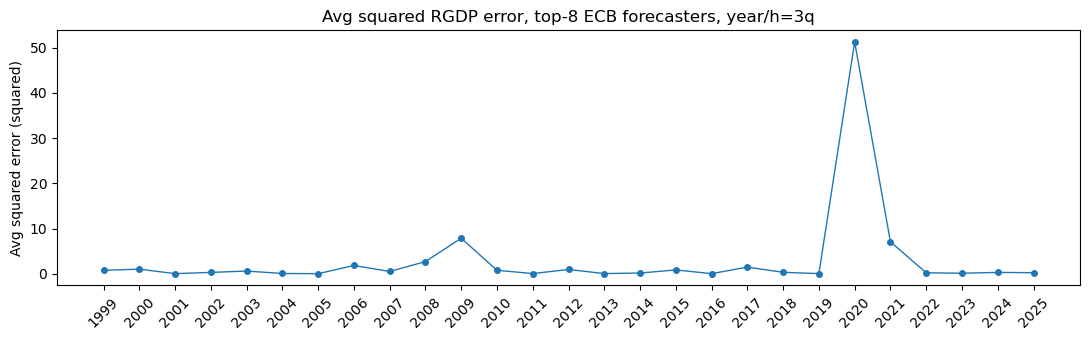

In [7]:
period_mse = X_panel.mean(axis=1)
print('Top 10 targets with highest average squared error:')
print(period_mse.nlargest(10).round(3))

plt.figure(figsize=(11, 3.5))
plt.plot(X_panel.index, period_mse, marker='o', linewidth=1, markersize=4)
plt.xticks(rotation=45)
plt.ylabel(f'Avg squared error ({METRIC})')
plt.title(f'Avg squared RGDP error, top-{N} ECB forecasters, '
          f'{TARGET_KIND}/h={HORIZON_Q}q')
plt.tight_layout()
plt.show()

## 7. Marginal CIs

In [8]:
out_marg = rank_ci_marginal_pairwise(X, alpha=0.1, B=5000, seed=42)

results_marg = pd.DataFrame({
    'ID':       population_ids,
    'MSE':      out_marg['theta_hat'].round(4),
    'RMSE':     np.sqrt(out_marg['theta_hat']).round(4),
    'cv_j':     out_marg['critical_values'].round(3),
    'CI_lower': out_marg['rank_ci'][:, 0],
    'CI_upper': out_marg['rank_ci'][:, 1],
}).sort_values('MSE')
results_marg.index = range(1, len(results_marg) + 1)
results_marg.index.name = 'Rank'
print(results_marg.to_string())
results_marg

      ID     MSE    RMSE   cv_j  CI_lower  CI_upper
Rank                                               
1     95  2.6543  1.6292  2.752         1         8
2     23  2.6650  1.6325  2.551         1         8
3     32  2.6725  1.6348  3.025         1         8
4     39  2.7874  1.6695  2.610         1         8
5     16  3.0870  1.7570  3.159         1         8
6     89  3.1566  1.7767  2.578         1         8
7     20  3.1896  1.7860  2.897         1         8
8     15  3.6782  1.9179  2.609         1         8


,ID,MSE,RMSE,cv_j,CI_lower,CI_upper
Rank,,,,,,
1,95,2.6543,1.6292,2.752,1,8
2,23,2.6650,1.6325,2.551,1,8
3,32,2.6725,1.6348,3.025,1,8
4,39,2.7874,1.6695,2.610,1,8
5,16,3.0870,1.7570,3.159,1,8
6,89,3.1566,1.7767,2.578,1,8
7,20,3.1896,1.7860,2.897,1,8
8,15,3.6782,1.9179,2.609,1,8


## 8. τ-best confidence set

Algorithm 3.3 of Mogstad et al. (2024). At $\alpha = 0.2$, $\tau \in \{1,2,3\}$.

In [9]:
ALPHA_TAU = 0.2
B_TAU     = 5000
SEED_TAU  = 42

out_rank = rank_ci_stepwise_pairwise(
    X, alpha=ALPHA_TAU, B=B_TAU, seed=SEED_TAU, verbose=False,
)

rows = []
for tau in [1, 2, 3]:
    res   = tau_best_pairwise(X, tau=tau, alpha=ALPHA_TAU, B=B_TAU,
                              seed=SEED_TAU, verbose=False)
    naive = tau_best_from_rank_ci(out_rank['rank_ci'], tau=tau)
    rows.append({
        'tau':           tau,
        'n_direct':      int(res['n_in_set']),
        'set_direct':    [population_ids[j] for j, v in enumerate(res['tau_best_set']) if v],
        'n_naive':       int(naive.sum()),
        'set_naive':     [population_ids[j] for j, v in enumerate(naive) if v],
        'max_test_stat': round(float(np.nanmax(res['test_stats'])), 3),
    })

tau_sweep = pd.DataFrame(rows).set_index('tau')
print(f'alpha = {ALPHA_TAU}, B = {B_TAU}, p = {len(population_ids)}')
print(f'Forecaster IDs: {population_ids}\n')
print(tau_sweep.to_string())
tau_sweep

alpha = 0.2, B = 5000, p = 8
Forecaster IDs: [16, 32, 39, 89, 95, 15, 20, 23]

     n_direct                        set_direct  n_naive                         set_naive  max_test_stat
tau                                                                                                      
1           8  [16, 32, 39, 89, 95, 15, 20, 23]        8  [16, 32, 39, 89, 95, 15, 20, 23]          2.010
2           8  [16, 32, 39, 89, 95, 15, 20, 23]        8  [16, 32, 39, 89, 95, 15, 20, 23]          1.974
3           8  [16, 32, 39, 89, 95, 15, 20, 23]        8  [16, 32, 39, 89, 95, 15, 20, 23]          1.930


,n_direct,set_direct,n_naive,set_naive,max_test_stat
tau,,,,,
1,8,"[16, 32, 39, 89, 95, 15, 20, 23]",8,"[16, 32, 39, 89, 95, 15, 20, 23]",2.010
2,8,"[16, 32, 39, 89, 95, 15, 20, 23]",8,"[16, 32, 39, 89, 95, 15, 20, 23]",1.974
3,8,"[16, 32, 39, 89, 95, 15, 20, 23]",8,"[16, 32, 39, 89, 95, 15, 20, 23]",1.930


## 9. Pre-COVID subsample (targets before 2021)

Same idea as in `HICP_CI.ipynb` §11. We restrict to target periods strictly
before 2021 while keeping the **same forecaster set** from §4, so the
comparison isolates the effect of dropping COVID-era targets from any
change in panel selection. If the COVID/post-COVID episode is what's keeping
RGDP CIs uninformative, $\max|t|$ should rise materially.

In [14]:
CUTOFF_YEAR = 2019

target_year = pd.to_numeric(X_wide.index.astype(str).str.slice(0, 4),
                            errors='coerce')
mask_pre = target_year < CUTOFF_YEAR

X_panel_pre = X_panel.loc[mask_pre]
X_pre       = X_panel_pre.values
ids_pre     = X_panel_pre.columns.tolist()
assert ids_pre == population_ids   # same forecasters by construction

dropped = [t for t in X_panel.index if t not in X_panel_pre.index]
print(f'Full sample:     {X_panel.shape[0]} targets')
print(f'Pre-{CUTOFF_YEAR} sample: {X_panel_pre.shape[0]} targets')
print(f'Targets dropped: {dropped}')
print(f'Per-forecaster obs in pre-{CUTOFF_YEAR}: '
      f'{X_panel_pre.notna().sum().to_dict()}')

Full sample:     27 targets
Pre-2019 sample: 20 targets
Targets dropped: ['2019', '2020', '2021', '2022', '2023', '2024', '2025']
Per-forecaster obs in pre-2019: {16: 20, 32: 20, 39: 20, 89: 20, 95: 20, 15: 19, 20: 19, 23: 19}


In [15]:
out_pre = rank_ci_stepwise_pairwise(X_pre, alpha=0.05, B=5000, seed=42)

results_pre = pd.DataFrame({
    'ID':       ids_pre,
    'MSE':      out_pre['theta_hat'].round(4),
    'RMSE':     np.sqrt(out_pre['theta_hat']).round(4),
    'CI_lower': out_pre['rank_ci'][:, 0],
    'CI_upper': out_pre['rank_ci'][:, 1],
}).sort_values('MSE')
results_pre.index = range(1, len(results_pre) + 1)
results_pre.index.name = 'Rank'
print(results_pre.to_string())
results_pre

=== Pairwise shared observations ===
  Min: 18, Mean: 19.2, Max: 20
  Pairs with < 20 shared obs: 36

=== Test statistics (delta_hat / se) ===
  Max: 2.0341, Pairs with t > 1.96: 1
      ID     MSE    RMSE  CI_lower  CI_upper
Rank                                        
1     32  0.7485  0.8651         1         8
2     23  0.8216  0.9064         1         8
3     95  0.8806  0.9384         1         8
4     16  0.9210  0.9597         1         8
5     20  0.9782  0.9890         1         8
6     39  1.0223  1.0111         1         8
7     89  1.3601  1.1662         1         8
8     15  1.4902  1.2207         1         8


,ID,MSE,RMSE,CI_lower,CI_upper
Rank,,,,,
1,32,0.7485,0.8651,1,8
2,23,0.8216,0.9064,1,8
3,95,0.8806,0.9384,1,8
4,16,0.9210,0.9597,1,8
5,20,0.9782,0.9890,1,8
6,39,1.0223,1.0111,1,8
7,89,1.3601,1.1662,1,8
8,15,1.4902,1.2207,1,8


## 10. Side-by-side informativeness summary

The diagnostic that matters: how does dropping 2021-2025 move
`max|t_{jk}|`, the share of pairs above the simultaneous critical value, and
the rank CI width? Following the convention in
`notebooks/philly/CI_INFORMATIVENESS.ipynb` (on the `ci-informativeness`
branch), informative CIs require **`max|t| > 3`** roughly, and at least a few
pairs crossing that threshold.

In [16]:
def _summary(X_arr, label, alpha=0.05, B=5000, seed=42):
    delta, se, n_pairs = compute_pairwise(X_arr, se_method='nw')
    t = np.abs(delta / se)
    valid = np.isfinite(t)
    tv = t[valid]
    theta = np.nanmean(X_arr, axis=0)
    out_ci = rank_ci_stepwise_pairwise(X_arr, alpha=alpha, B=B,
                                       seed=seed, verbose=False)
    widths = out_ci['rank_ci'][:, 1] - out_ci['rank_ci'][:, 0] + 1
    return {
        'sample':         label,
        'n_targets':      X_arr.shape[0],
        'p':              X_arr.shape[1],
        'min_overlap':    int(n_pairs[n_pairs > 0].min()),
        'theta_min':      float(theta.min()),
        'theta_max':      float(theta.max()),
        'theta_max/min':  float(theta.max() / theta.min()),
        'max_|t|':        float(tv.max()),
        '%_|t|>1.96':     float((tv > 1.96).mean() * 100),
        '%_|t|>3':        float((tv > 3.0).mean() * 100),
        'CI_mean_width':  float(widths.mean()),
        'CI_max_width':   int(widths.max()),
        'CI_#singletons': int((widths == 1).sum()),
        'CI_full':        bool(widths.max() == X_arr.shape[1]),
    }

summary = pd.DataFrame([
    _summary(X,     'full (1999-2025)'),
    _summary(X_pre, f'pre-{CUTOFF_YEAR}     '),
]).set_index('sample').T
with pd.option_context('display.float_format', '{:.3g}'.format):
    print(summary)
summary

sample         full (1999-2025) pre-2019     
n_targets                    27            20
p                             8             8
min_overlap                  25            18
theta_min                  2.65         0.748
theta_max                  3.68          1.49
theta_max/min              1.39          1.99
max_|t|                    2.01          2.03
%_|t|>1.96                 7.14          3.57
%_|t|>3                       0             0
CI_mean_width                 8             8
CI_max_width                  8             8
CI_#singletons                0             0
CI_full                    True          True


sample,full (1999-2025),pre-2019
n_targets,27,20
p,8,8
min_overlap,25,18
theta_min,2.654307,0.748451
theta_max,3.678214,1.490156
theta_max/min,1.385753,1.990987
max_|t|,2.009752,2.034097
%_|t|>1.96,7.142857,3.571429
%_|t|>3,0.0,0.0
CI_mean_width,8.0,8.0


In [13]:
# τ-best on pre-2021 panel
out_rank_pre = rank_ci_stepwise_pairwise(
    X_pre, alpha=ALPHA_TAU, B=B_TAU, seed=SEED_TAU, verbose=False,
)

rows_pre = []
for tau in [1, 2, 3]:
    res   = tau_best_pairwise(X_pre, tau=tau, alpha=ALPHA_TAU, B=B_TAU,
                              seed=SEED_TAU, verbose=False)
    naive = tau_best_from_rank_ci(out_rank_pre['rank_ci'], tau=tau)
    rows_pre.append({
        'tau':           tau,
        'n_direct':      int(res['n_in_set']),
        'set_direct':    [ids_pre[j] for j, v in enumerate(res['tau_best_set']) if v],
        'n_naive':       int(naive.sum()),
        'set_naive':     [ids_pre[j] for j, v in enumerate(naive) if v],
        'max_test_stat': round(float(np.nanmax(res['test_stats'])), 3),
    })

tau_sweep_pre = pd.DataFrame(rows_pre).set_index('tau')
print(f'Pre-{CUTOFF_YEAR} — alpha = {ALPHA_TAU}, B = {B_TAU}, p = {len(ids_pre)}')
print(f'Forecaster IDs: {ids_pre}\n')
print(tau_sweep_pre.to_string())
tau_sweep_pre

Pre-2021 — alpha = 0.2, B = 5000, p = 8
Forecaster IDs: [16, 32, 39, 89, 95, 15, 20, 23]

     n_direct                        set_direct  n_naive                         set_naive  max_test_stat
tau                                                                                                      
1           8  [16, 32, 39, 89, 95, 15, 20, 23]        8  [16, 32, 39, 89, 95, 15, 20, 23]          2.372
2           8  [16, 32, 39, 89, 95, 15, 20, 23]        8  [16, 32, 39, 89, 95, 15, 20, 23]          2.013
3           8  [16, 32, 39, 89, 95, 15, 20, 23]        8  [16, 32, 39, 89, 95, 15, 20, 23]          2.012


,n_direct,set_direct,n_naive,set_naive,max_test_stat
tau,,,,,
1,8,"[16, 32, 39, 89, 95, 15, 20, 23]",8,"[16, 32, 39, 89, 95, 15, 20, 23]",2.372
2,8,"[16, 32, 39, 89, 95, 15, 20, 23]",8,"[16, 32, 39, 89, 95, 15, 20, 23]",2.013
3,8,"[16, 32, 39, 89, 95, 15, 20, 23]",8,"[16, 32, 39, 89, 95, 15, 20, 23]",2.012
